# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [58]:

# importar librerías
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np

In [59]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') 
usage = pd.read_csv('/datasets/usage.csv')

In [60]:
plans.head() # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [61]:
users.head() # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [62]:
usage.head() # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [63]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [64]:
plans.info() # inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [65]:
users.info() # inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [66]:
usage.info() # inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [67]:
# cantidad de nulos para users
print(plans.isna().sum()) # Cantidad de valores nulos)
print() 
print(plans.isna().mean()) # Proporción de valores nulos)

plan_name            0
messages_included    0
gb_per_month         0
minutes_included     0
usd_monthly_pay      0
usd_per_gb           0
usd_per_message      0
usd_per_minute       0
dtype: int64

plan_name            0.0
messages_included    0.0
gb_per_month         0.0
minutes_included     0.0
usd_monthly_pay      0.0
usd_per_gb           0.0
usd_per_message      0.0
usd_per_minute       0.0
dtype: float64


In [68]:

print(usage.isna().sum()) 
print() 
print(usage.isna().mean()) # cantidad de nulos para usage


id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


In [69]:
def calcular_nulos(x):
    return x.isna().mean()

usage.groupby('type')[['duration', 'length']].apply(calcular_nulos)

,duration,length
type,,
call,0.000000,0.99933
text,0.999276,0.00000


In [70]:
usage.count()


id          40000
user_id     40000
type        40000
date        39950
duration    17924
length      22104
dtype: int64

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
* Del dataset usage la columna date: proporcion minima, se deja como nulos esas 50 filas sin afectar el analisi
* Columna `duration`: de acuerdo a la proporcion 55% se dejan como nulos.
* Columna `length` 44% se dejan como nulos.
- Indica qué harías: ¿imputar, eliminar, ignorar?
* Se ignoran los nulos
  

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [71]:
users.nunique().sort_values() # explorar columnas numéricas de users

plan             2
last_name        5
first_name       6
city             7
age             63
churn_date     197
reg_date      3961
user_id       4000
dtype: int64

- La columna `user_id` nos indica que hay 2 tipos de planes de telefono. 
- La columna `age` hay 63 valores unicos de edades.

In [72]:
usage.nunique().sort_values() # explorar columnas numéricas de usage

type            2
length        123
duration     2090
user_id      3999
date        39950
id          40000
dtype: int64

- La columna `id`, indica que hay 40,000 valores unicos y `user_id`: la cantidad es mucho menor que el `id` haciendo referencia que los usuarios se repiten durante el dataset (mismos clientes repetidos con diferentes compras).
- La columna `lentgh` hace referencia a los caracteres de una texto(sms) y `duration` hace referencia a segunso y minutos que duran las llamadas telefonicas.

In [73]:
# explorar columnas categóricas de users
columnas_users = ['city', 'plan']

for col in columnas_users:
    print(f"Columna:", col)
    print (users[col].value_counts())
    print(f"Valores únicos:", users[col].nunique())
    print()

Columna: city
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Valores únicos: 7

Columna: plan
Basico     2595
Premium    1405
Name: plan, dtype: int64
Valores únicos: 2



- La columna `city` indica uwe hay 7 valores unicos, pero en realidad serian 6 valores unicos ya que el "7" es un sentinel y se tiene que convertir ese valor a "NaN" o "desconocido", para que no afecte el analisis y dejarlo como valor nulo o ignorarlo.
- La columna `plan` hay 2 valores unicos de los cuales 25095 ususarios tiene el paquete "Basico" y 1405 usuarios tiene el paquete "Premium".

In [74]:
# explorar columna categórica de usage
usage['type'].value_counts() # completa el código

text    22092
call    17908
Name: type, dtype: int64

- La columna `type`indica que hay en su categoria "text" 22092 registros de text y 17908 registros de "call" de los 40,000 valores que tiene esta columna "type.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- En la columna city hay una categoria que no tiene nombre, eso se toma como un sentine o invalido. 
- ¿Qué acción tomarías?
- Convertir esa categoria "?" por un marcador como NaN o "Desconocido" e ignorarlo. 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [75]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código

In [76]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código

In [77]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts().sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`,tenemos desde el anio 2022 hasta el 2026 saltandose el 2025 teniendo registros hasta el anio 2024 es imposible que esos 40 registros de la fecha 2026 sean reales. 

In [78]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts().sort_index())

2024.0    39950
Name: date, dtype: int64


In [79]:
print("Fechas nulas (NaT) en date:", usage['date'].isna().sum())

Fechas nulas (NaT) en date: 50


En `date`, indica que esa columna es consistente, ya que son registros de ese mismo anio 2024 sin anios futuros o negativos teniendo 50 valores que no pudieron convertirse y quedan como NaT.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- En el dataset users aparece desde el año 2022 hasta el 2026 saltandose 2025, teniendo inconsistencia en esa parte se toman como valores invalidos 2026 (40) marcandolos como NaT(Not a Time).
- ¿Qué harías con ellas?
- En el dataset de users se tomarian como valores invalidos NaT los del año 2026, relativamente son pocos que no afectaria el dataset, podriamos ignorarlos.
- en el dataset usage tiene mayor consistencia ya que los regsitros son del año 2024, sin embargo tenemos 50 registros nulos, de igual manera se ignorarian. 

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [80]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median() 
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [81]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", pd.NA)

# Verificar cambios
users['city'].value_counts()
print("Valores ausentes en city:", users['city'].isna().sum())

Valores ausentes en city: 565


In [82]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year> 2024, 'reg_date'] =pd.NaT

# Verificar cambios
print("Fechas futuras restantes:", (users['reg_date'].dt.year > 2024).sum())
print("Total de valores ausentes en reg_date:", users['reg_date'].isna().sum())

Fechas futuras restantes: 0
Total de valores ausentes en reg_date: 40


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [83]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [84]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

- 99% de nulos en duration para text y en length para call.

- Dejar como NaN para no alterar columnas.

- Cada categoría de `type` tiene su correlación con duration y length.

- Siendo  MNAR, ya que los nulos no son aleatorios, sino completamente predecibles según el tipo de evento.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [85]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
   'is_text':'sum',
   'is_call':'sum',
   'duration':'sum'
})

# observar resultado
usage_agg.head(3)

,is_text,is_call,duration
user_id,,,
10000,7,3,23.70
10001,5,10,33.18
10002,5,2,10.74


In [86]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns ={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,cant_mensajes,cant_llamadas,cant_minutos_llamada
user_id,,,
10000,7,3,23.70
10001,5,10,33.18
10002,5,2,10.74


In [87]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [88]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.122250,5.524381,4.478120,23.317054
std,1154.844867,17.690408,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,47.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [89]:
# Distribución porcentual del tipo de plan
users['plan'].value_counts(normalize=True)

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

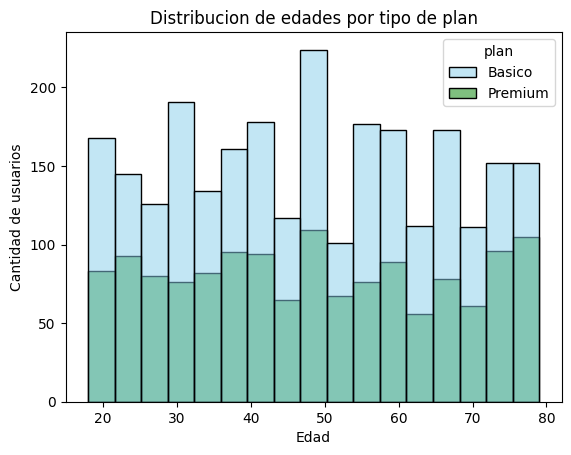

In [90]:
# Histograma para visualizar la edad (age)

sns.histplot(user_profile, x='age', hue='plan', palette=['skyblue', 'green'])

plt.title('Distribucion de edades por tipo de plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


💡Insights: La distribucion de edades es bastante uniforme, se puede observar que la proporcion relativa va entre los 35-50  y 75-80 años la distribucion del plan `Premium` domina en estos grupos etarios; sin embargo en las edades mas jovenes 18-30 y 50-70 años el plan `Basico` se ve con entaja mas clara ante del `Premium`.
- Distribución simetrica.

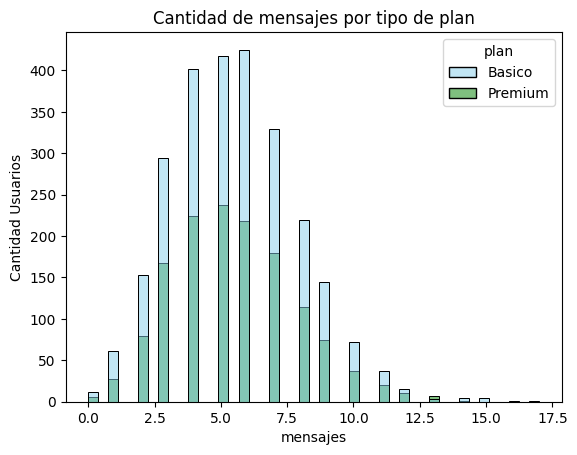

In [91]:
# Histograma para visualizar la cant_mensajes
sns.histplot(user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'])

plt.title('Cantidad de mensajes por tipo de plan')
plt.xlabel('mensajes')
plt.ylabel('Cantidad Usuarios')
plt.show()

💡Insights: La proporción entre planes, se observa que el plan `Premium` representa una porción consistentemente alta y en algunos bins incluso mayoritaria del total, especialmente en el rango central (3-8 mensajes), donde Premium llega a representar más de la mitad de cada barra. Esto sugiere que los usuarios Premium tienden a enviar una cantidad similar o incluso mayor de mensajes que los usuarios Básico, a pesar de que en volumen total el plan Básico sigue siendo más numeroso.

- La distribución de cantidad de mensajes muestra un sesgo a la derecha con la mayoría de los usuarios enviando entre 4 y 7 mensajes, donde se concentra el pico de la distribución (con máximos alrededor de 5-6 mensajes). Muy pocos usuarios superan los 10 mensajes.

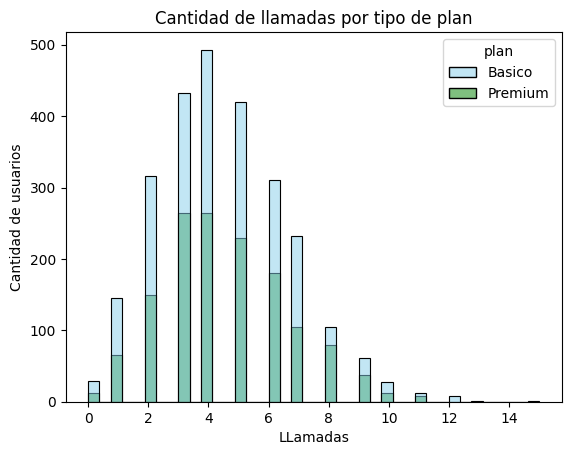

In [92]:
# Histograma para visualizar la cant_llamadas
sns.histplot(user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'])

plt.title('Cantidad de llamadas por tipo de plan')
plt.xlabel('LLamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: Al igual que con los mensajes, no hay una diferencia dramática en el patrón de llamadas entre planes, ambos siguen una distribución similar centrada en pocas llamadas. Sin embargo, la fuerte presencia de usuarios Premium en el rango de mayor actividad de 3-7 llamadas refuerza la idea de que los usuarios Premium mantienen un nivel de uso comparable o incluso superior al de Básico, tanto en mensajería como en llamadas, sugiriendo que el plan Premium no está asociado a bajo consumo, sino a un perfil de usuario más activo en general.

- Distribución con sesgo a la derecha con la mayoría de los usuarios haciendo entre 3 y 5 llamadas, donde se concentra el pico máximo cercano a las 4 llamadas. Muy pocos usuarios superan las 10 llamadas.

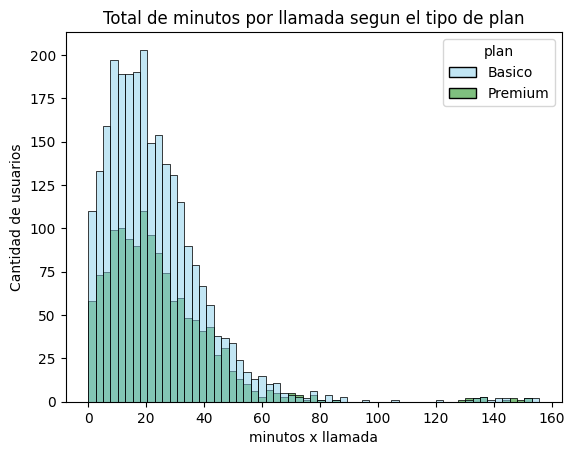

In [93]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'])

plt.title('Total de minutos por llamada segun el tipo de plan')
plt.xlabel('minutos x llamada')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: En cuanto a la proporción entre planes, aquí sí se nota una diferencia más marcada respecto a los gráficos anteriores: el plan `Básico` domina claramente en el rango de mayor concentración (10-40 minutos), mientras que `Premium` mantiene una presencia más estable pero proporcionalmente menor en ese tramo central. Sin embargo, en la cola derecha (valores atípicos por encima de 100 minutos), ambos planes aparecen de forma dispersa y en cantidades muy bajas, sin un patrón claro de dominancia.


- La distribución del total de minutos por llamada muestra una fuerte sesgo hacia la derecha, con la mayoría de los usuarios concentrados entre 0 y 40 minutos, y un pico claro alrededor de los 15-20 minutos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

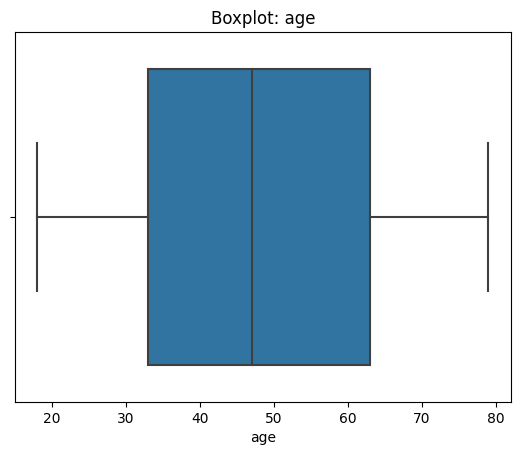

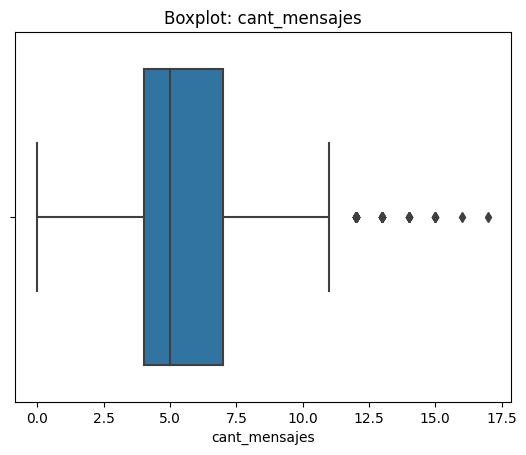

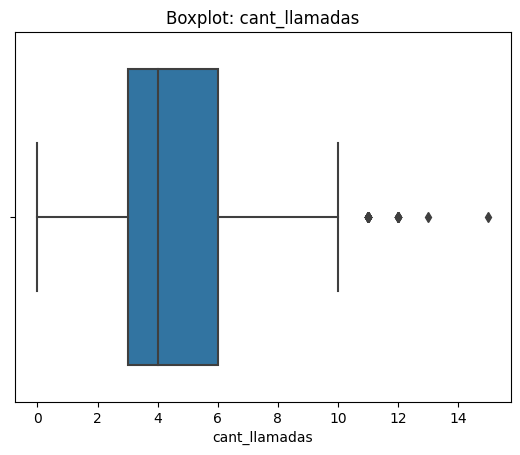

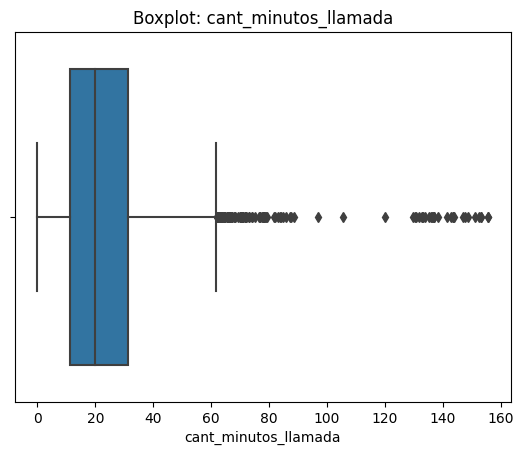

In [94]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
columnas_numericas 

for col in columnas_numericas: 
    sns.boxplot(x=user_profile [col])
    plt.title(f'Boxplot: {col}')
    plt.show()

    

💡Insights: 
- Age: La mediana se ubica en 47 años, con el rango intercuartilico entre 33 y 63 años, mostrando una dispersion bastante amplia y una distribucion simetrica de edades entre los usuarios.
No se detectan outliers: los bigotes se extienden desde 18 hasta 79 años sin puntos fuera de ese rango, lo que indica que la edad es una variable limpia y sin valores atípicos 

- cant_mensajes: La mediana se ubica en 5 mensajes, con el 50% central de los usuarios (rango intercuartilico) entre 4 y 7 mensajes, lo que indica un comportamiento de mensajeria bastante uniforme entre la mayoria de los usuarios.
Se detectan outliers a partir de aproximadamente 12 mensajes en adelante (hasta 17), representados como puntos individuales fuera del bigote superior. Son relativamente pocos, pero marcan usuarios con un uso de mensajería notablemente más alto que el resto.

- cant_llamadas: La mediana se ubica en 4 llamadas, con el rango intercuartilico entre 3 y 6 llamadas, mostrando un comportamiento de llamadas también bastante concentrado y consistente entre la mayoría de los usuarios.
Se detectan outliers a partir de aproximadamente 11 llamadas en adelante (hasta 15), representados como puntos aislados fuera del bigote superior. Son pocos casos, pero identifican usuarios con una frecuencia de llamadas considerablemente mayor al resto, un patrón similar al observado en mensajes, lo que podría indicar que se trata del mismo segmento de usuarios de alto consumo general.

- cant_minutos_llamada: La mediana se ubica en 20 minutos, con el rango intercuartilico entre 10 y 30 minutos, mostrando que la mayoria de los usuarios acumula un total de llamadas moderado.
A diferencia de los boxplots anteriores, aqui se observa una cantidad mucho mayor y mas dispersa de outliers, extendiendose desde 65 minutos hasta mas de 150 minutos, con varios puntos incluso mas alla de los 130-155. Esto indica una cola larga de usuarios de uso intensivo, mucho mas pronunciada que en mensajes o llamadas, sugiriendo que, aunque la mayoría usa el servicio de forma moderada, existe un grupo considerable de usuarios con un volumen de minutos notablemente atipico, que valdria la pena investigar por separado (posible segmento de alto valor).

In [95]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)
    IQR = q3 - q1 
    limite_superior = q3 + 1.5 * IQR

print(f'col : {limite_superior}')    

col : 61.8575


In [96]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
  * Mantener outliers teniendo como maximo 17 mensajes en algunos usuarios es un valor real, no imposible y eliminarlos descartaria la posibilidad de calcular a los ususarios potenciales. 
- cant_llamadas: mantener o no outliers, porqué?
  * De igual manera que la columna anterior, el maximo de llamadas (15) es un dato real para susuarios activos, se deben de mantener los outliers, son datos reales, eliminarlos afectaria nuestro analisis de clientes potenciales. 
- cant_minutos_llamada: mantener o no outliers, porqué?
  * Aqui se tendrian que revisar a mas detalle, sin embargo la cantidad de minutos por llamada se puede deber a factores como llamadas largas laborales o soporte tecnico, debido a que son outliers extremos podrian marcarse para identificarlos, no se recomienda eliminarlos.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [101]:
# Crear columna grupo_uso
def clasificar_uso(fila):
    if fila['cant_llamadas'] < 5 and fila['cant_mensajes'] < 5:
        return 'Bajo uso'
    
    elif fila['cant_llamadas'] < 10 and fila['cant_mensajes'] <10: 
        return 'Uso medio'

    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

print(user_profile['grupo_uso'].value_counts(normalize=True) * 100)

Uso medio    73.575
Bajo uso     19.450
Alto uso      6.975
Name: grupo_uso, dtype: float64


In [103]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [102]:
# Crear columna grupo_edad
def clasificar_edad(fila):
    if fila['age'] <30:
        return "Joven"

    elif fila['age'] <60:
        return "Adulto"

    else:
        return "Adulto Mayor"

user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)

print(user_profile['grupo_edad'].value_counts(normalize=True) * 100)

Adulto          50.45
Adulto Mayor    30.55
Joven           19.00
Name: grupo_edad, dtype: float64


In [104]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data = user_profile, x = 'grupo_uso', order=['Bajo uso', 'Uso medio', 'Alto uso'], color='skyblue')
plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data = user_profile, x = 'grupo_edad', order=['Joven', 'Adulto', 'Adulto Mayor'], color='skyblue')
plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

1. Calidad inicial de los datos
El dataset presentaba varios problemas que requirieron limpieza antes de un análisis confiable:

* Valores sentinels en age: la columna contenía el valor -999 como marcador de dato faltante, afectando 47 registros lo que distorsionaba la media y desviación estándar real de la edad.

Ciudades inválidas: la columna city tenía el valor "?" en 96 registros (≈2.4% del total de usuarios), representando datos faltantes disfrazados de categoría válida.

Fechas incorrectas o futuras: al convertir reg_date y date a formato de fecha, se detectaron aproximadamente 50 registros (~0.1%) que no pudieron convertirse correctamente o correspondían a fechas fuera del rango esperado (posteriores a 2024), y fueron marcados como valores ausentes (NaT).

En conjunto, estos problemas afectaban una porción pequeña pero significativa del dataset, lo que reforzó la necesidad de un pipeline de limpieza sistemático antes de segmentar usuarios.

2. Segmentos identificados
Se crearon dos ejes de segmentación:

Por edad (grupo_edad): los usuarios se distribuyen de forma uniforme entre los 18 y 80 años, sin un grupo etario dominante.

Por nivel de uso (grupo_uso): clasificados en Bajo uso (19.4%), Uso medio (73.5%) y Alto uso (6.9%) según su cantidad de llamadas y mensajes. 

Al cruzar ambos ejes, se observó que el plan Premium mantiene una proporción relativa más alta en usuarios de mediana edad (35-50 años) y adultos mayores (75+), mientras que el plan Básico domina en el resto de los rangos etarios, sin diferencias dramáticas en el patrón general de uso (mensajes y llamadas) entre planes.

3. Segmentos más valiosos

Los usuarios de Alto uso, especialmente aquellos concentrados en el rango etario 35-50 años con plan Premium, representan el segmento más valioso para ConnectaTel: combinan alta frecuencia de interacción (mensajes y llamadas) con mayor disposición a pagar por un plan premium, lo que sugiere mayor lealtad y potencial de ingreso recurrente.

4. Patrones de uso extremo (outliers)

En cant_mensajes y cant_llamadas, los outliers (usuarios con 12-17 mensajes o 11-15 llamadas) son moderados y consistentes con comportamiento real de "usuarios potenciales", no representan errores de datos.

En cant_minutos_llamada, se identificó una cola de outliers mucho más extensa y extrema, con valores de hasta 155 minutos frente a un 
límite superior esperado de ~62 minutos. Esto sugiere un subgrupo de usuarios con sesiones de llamada inusualmente largas, que podría representar tanto comportamiento legítimo (ej. uso profesional o soporte) como necesitar revisión adicional para descartar errores de registro.

Implicación de negocio: este segmento de alto consumo en minutos podría beneficiarse de un plan con tarifas diferenciadas por volumen de minutos, en vez de aplicar la tarifa estándar que probablemente no está optimizada para ese patrón de uso.

5. Recomendaciones

Plan intermedio "Plus": crear una oferta entre Básico y Premium dirigida a usuarios de Uso medio, que actualmente podrían estar sub-atendidos por los dos planes existentes.

Plan de minutos ilimitados o por volumen: dado el patrón extremo detectado en cant_minutos_llamada, diseñar un plan específico para el segmento de alto consumo de minutos, capturando ingresos de usuarios que hoy podrían estar excediendo los límites de su plan actual sin una oferta adecuada.

Estrategia de retención para 35-50 años: reforzar beneficios del plan Premium hacia este grupo etario, ya que muestra mayor propensión a pagar por el servicio premium y representa el segmento de mayor valor.

Mejorar la captura de datos: implementar validaciones en el formulario de registro (ciudad, edad, fecha) para reducir valores centinela (-999, "?") y fechas inválidas, mejorando la calidad de futuros análisis sin depender de limpieza despues de que los datos ya fueron cargados.

Prevenir ese tipo de errores desde el inicio, evitando que en el sistema aparezca -999 o "?".

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- abc
- abc


🔍 **Segmentos por Edad**
- abc
- abc 


📊 **Segmentos por Nivel de Uso**
- abc
- abc


➡️ Esto sugiere que ...


💡 **Recomendaciones**
- abc
- abc 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`